In [1]:
import numpy as np
import pandas as pd
from torch import nn
from torchvision import transforms 
from torchvision import datasets 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import cv2
from PIL import Image
import sklearn



RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

In [2]:

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),

    ])  
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),      
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    # transforms.RandomGrayscale(p=0.1),     
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
])

In [3]:
trainData = datasets.ImageFolder(root="../data/train", transform=train_transform)
train_loader = DataLoader(trainData, batch_size=32, shuffle=True)
testData = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(testData, batch_size=32, shuffle=False)
valData = datasets.ImageFolder(root="../data/val", transform=test_transform)
val_loader = DataLoader(valData, batch_size=32, shuffle=False)


In [4]:
class ConvNeuralNet(nn.Module) : 
    def __init__(self, num_classes = 2):
        super(ConvNeuralNet, self).__init__() 
        self.convoLayer1 = nn.Conv2d(3,16,3,stride=1) 
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer2 = nn.Conv2d(16,32,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer3 = nn.Conv2d(32,64,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten() 
        self.dropout = nn.Dropout(0.5)  # ✅ ajouté ici

        self.fc1 = nn.Linear(43264, 512) 
        self.output = nn.Linear(512, num_classes) 
        #lvaleur l theny hwa nbr de classes de sortie
    def forward(self, x): 
        out = self.convoLayer1(x)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer3(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.flatten(out)
        # out = out.view(out.size(0), -1)
        out = self.dropout(out)  # ← juste avant fc1
        out = self.fc1(out)
        out = self.output(out)
        return out
    

torch.Size([32, 3, 224, 224])


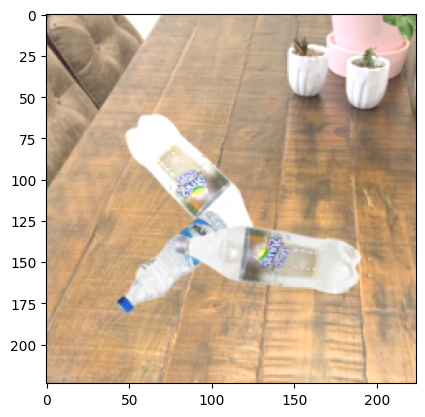

In [5]:
for images, labels in train_loader:
    print(images.shape)  
    img = images[1]
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.show()
    break  

In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
# import torch
# torch.cuda.empty_cache()

In [8]:
model = ConvNeuralNet(num_classes=2) 
model = model.to(device) 
loss_fct = nn.CrossEntropyLoss()
#optimoizer : bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 


In [9]:
print(torch.version.cuda)      # what version pytorch speaks


13.0


In [10]:
print(train_loader.dataset.classes)  # to know the classes of the dataset

['SodaBottle', 'WaterBottle']


In [11]:
vl = []
tr = []
for j in range (10) : #9adeh men mara kol image bch ysirlha training (passage par tous les couches)
    train_loss = 0.0
    model.train() # Set the model to training mode

    for i, (images, labels) in enumerate(train_loader): #images heya x li f modéle
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) 
        loss = loss_fct(outputs, labels)
        optimizer.zero_grad() #bch naamlou reset ll les gradients mteena
        loss.backward() #bch naamlou calcul ll les gradients mteena
        optimizer.step() #bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
        train_loss += loss.item()
    train_loss /= len(train_loader)
    tr.append(train_loss)

    with torch.no_grad():
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = loss_fct(outputs, labels)
                val_loss += loss.item()
    val_loss /= len(val_loader)
    vl.append(val_loss)

    print('Epoch [{}/{}], Loss: {:.4f} , val_loss: {:.4f}' .format(j+1, 20, train_loss, val_loss))

c:\Users\LENOVO\anaconda3\envs\DigitalEyes\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20], Loss: 0.1051 , val_loss: 0.0147
Epoch [2/20], Loss: 0.0243 , val_loss: 0.0165
Epoch [3/20], Loss: 0.0284 , val_loss: 0.0119
Epoch [4/20], Loss: 0.0181 , val_loss: 0.0106
Epoch [5/20], Loss: 0.0151 , val_loss: 0.0107
Epoch [6/20], Loss: 0.0177 , val_loss: 0.0095
Epoch [7/20], Loss: 0.0113 , val_loss: 0.0066
Epoch [8/20], Loss: 0.0105 , val_loss: 0.0111
Epoch [9/20], Loss: 0.0083 , val_loss: 0.0085
Epoch [10/20], Loss: 0.0047 , val_loss: 0.0073


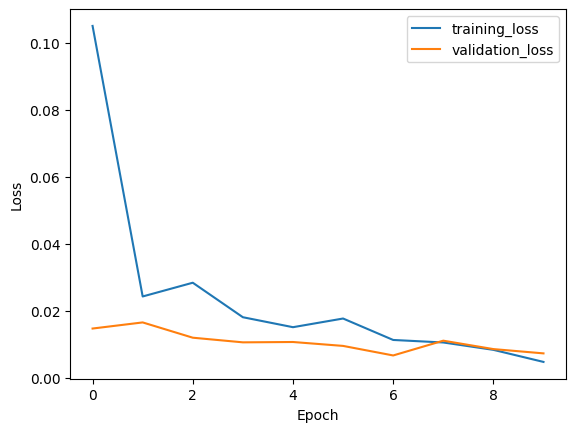

In [12]:
import matplotlib.pyplot as plt

plt.plot(tr , label='training_loss')
plt.plot(vl, label='validation_loss')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Testing

In [20]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(total) 
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

8410
8401
Accuracy: 99.89%


In [21]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0) 
        correct += (predicted == labels).sum().item() 
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

1733
1730
Accuracy: 99.83%


In [15]:
# from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# with torch.no_grad():
#     all_predictions = []
#     all_labels = []
    
#     for images, labels in test_loader:
#         images = images.to(device)
#         labels = labels.to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs.data, 1)
         
#         all_predictions.extend(predicted.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())
    
#     recall = recall_score(all_labels, all_predictions)
#     precision = precision_score(all_labels, all_predictions)

#     print(f'Recall: {recall:.4f}')
#     print(f'Precision: {precision:.4f}')


In [ ]:
torch.save(model.state_dict(), 'model.pt')

In [17]:
# myCNN = ConvNeuralNet(num_classes=2)

In [18]:
# myCNN.load_state_dict(torch.load('model.pth'))
# myCNN.to(device)
# #charger les poids du modéle d'aprés fichier 'model.pth'

In [ ]:



import torch.nn.functional as F

# Now run the webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(image)
    image = train_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():  # ✅ indented inside the while loop
        outputs = myCNN(image)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        predicted_label = trainData.classes[predicted.item()]

    cv2.putText(frame, predicted_label, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow("Digital Eyes", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    print(outputs)


cap.release()
cv2.destroyAllWindows()

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

: 

: 

: 

: 

: 

In [ ]:
trainData.classes
trainData.class_to_idx



{'SodaBottle': 0, 'WaterBottle': 1}

: 

: 

: 

: 

: 

In [ ]:
image_path = "C:\\Users\\LENOVO\\Digital-Eyes\\CNNmodel\\fan.jpg"

def load_image(image_path):
    image = Image.open(image_path).convert('RGB')

    image = test_transform(image)
    return image.unsqueeze(0)  # Ajouter une dimension pour le batch

: 

: 

: 

: 

: 

In [ ]:
import torchvision

image = load_image(image_path)
image = image.to(device)

myCNN.eval()

with torch.no_grad():
    outputs = myCNN(image)
    _, predicted = torch.max(outputs, 1)
    predicted_label = trainData.classes[predicted.item()]
    

print(predicted_label)
outputs


SodaBottle


tensor([[ 7.6791, -7.6794]], device='cuda:0')

: 

: 

: 

: 

: 

In [ ]:
 # raka7 l quality of images urtout f soda folder ++ erjaa l e5er disc maa claude

: 

: 

: 

: 

: 

In [ ]:
testData.class_to_idx


{'SodaBottle': 0, 'WaterBottle': 1}

: 

: 

: 

: 

: 

In [ ]:
import cv2

: 

: 

: 

: 

: 

In [ ]:
# naamlou l hajet li similar kima milk juice // soda water // remote control phone // reading glasses sunglasses // 

: 

: 

: 

: 

: 